In [2]:
import glob
import os
import gc
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt


In [3]:
import tensorflow as tf

# GPU Memory Growth activation
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✓ GPU Memory Growth Enabled")
    except RuntimeError as e:
        print(e)

✓ GPU Memory Growth Enabled


In [4]:
# =================================================================
# ⚙️ GLOBAL CONFIGURATIONS
# =================================================================
IMG_HEIGHT, IMG_WIDTH = 224, 224
BATCH_SIZE = 16
EPOCHS = 30

# 📌 YOUR EXACT PATHS
MODEL_SAVE_PATH = "/mnt/c/development/Thesis/PolypSegmentationBasedClassification/models/try_unet_pd_pc_zscore/end_to_end_polyp_model.keras"
POSITIVE_DIR = "/mnt/c/development/Thesis/PolypSegmentationBasedClassification/DataSets/PolypGen2021_MultiCenterData_v2/imagesAll_positive"
NEGATIVE_DIR = "/mnt/c/development/Thesis/PolypSegmentationBasedClassification/DataSets/PolypGen2021_MultiCenterData_v2/sequenceData/negativeOnly"

In [5]:
# =================================================================
# 📊 DATA GENERATOR PIPELINE (Safe & Shuffled)
# =================================================================
def load_and_preprocess_image(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH])
    img = img / 255.0  # Min-Max normalization
    return img, label

In [6]:
def prepare_dataset():
    valid_extensions = ('*.png', '*.jpg', '*.jpeg', '*.bmp', '*.tif', '*.PNG', '*.JPG', '*.JPEG')
    pos_files, neg_files = [], []

    # Load Positive Images
    for ext in valid_extensions:
        pos_files.extend(glob.glob(os.path.join(POSITIVE_DIR, "**", ext), recursive=True))
        
    # Load Negative Images from seq1_neg to seq13_neg
    for i in range(1, 14): 
        folder_name = f"seq{i}_neg"
        target_folder_path = os.path.join(NEGATIVE_DIR, folder_name)
        if os.path.exists(target_folder_path):
            for ext in valid_extensions:
                neg_files.extend(glob.glob(os.path.join(target_folder_path, "**", ext), recursive=True))
            
    pos_files = [f for f in pos_files if os.path.isfile(f)]
    neg_files = [f for f in neg_files if os.path.isfile(f)]
    
    print(f"\n📊 Dataset Summary: Positive = {len(pos_files)} | Negative = {len(neg_files)}")
    
    file_paths = pos_files + neg_files
    labels = [1.0] * len(pos_files) + [0.0] * len(neg_files)
    
    file_paths = np.array(file_paths)
    labels = np.array(labels, dtype=np.float32)
    
    # Shuffle using fixed seed to keep arrays aligned
    np.random.seed(42)
    indices = np.arange(len(file_paths))
    np.random.shuffle(indices)
    
    file_paths = file_paths[indices]
    labels = labels[indices]
    
    # Split 80% Train, 20% Val
    split = int(0.8 * len(file_paths))
    
    train_ds = tf.data.Dataset.from_tensor_slices((file_paths[:split], labels[:split]))
    train_ds = train_ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    train_ds = train_ds.shuffle(buffer_size=1024).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    
    val_ds = tf.data.Dataset.from_tensor_slices((file_paths[split:], labels[split:]))
    val_ds = val_ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    
    return train_ds, val_ds

In [7]:
# =================================================================
# 🧠 CUSTOM PCC LAYER (INSIDE KERAS NETWORK GRAPH)
# =================================================================
@tf.keras.utils.register_keras_serializable()
class KerasPCCLayer(layers.Layer):
    """ Custom Keras Layer that computes feature correlation matrix inside the model. """
    def __init__(self, **kwargs):
        super(KerasPCCLayer, self).__init__(**kwargs)

    def call(self, inputs):
        epsilon = 1e-8
        # Normalize vectors across features axis
        mean = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        std = tf.math.reduce_std(inputs, axis=-1, keepdims=True) + epsilon
        norm_inputs = (inputs - mean) / std
        
        # Batch outer-product multiplication -> Matrix Shape: [Batch, 128, 128]
        pcc_matrix = tf.matmul(tf.expand_dims(norm_inputs, -1), tf.expand_dims(norm_inputs, 1))
        
        # Flatten back to 1D vector -> Shape: [Batch, 16384]
        return layers.Flatten()(pcc_matrix)

In [8]:

# =================================================================
# 🧱 THE NEW SIMPLE PC-CNN + PD-CNN ARCHITECTURE
# =================================================================
def build_simple_pc_pd_pcc_model():
    inputs = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
    
    # 1️⃣ STEP: PC-CNN Block (Parallel Convolutional Multi-Scale Kernels)
    conv_3x3 = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
    conv_5x5 = layers.Conv2D(32, (5, 5), padding='same', activation='relu')(inputs)
    conv_7x7 = layers.Conv2D(32, (7, 7), padding='same', activation='relu')(inputs)
    
    # Concatenate parallel feature maps along channel axis
    pc_cnn = layers.Concatenate()([conv_3x3, conv_5x5, conv_7x7])
    p1 = layers.MaxPooling2D((2, 2))(pc_cnn)
    
    # 2️⃣ STEP: PD-CNN Block (Depthwise Separable Optimization)
    pd_cnn = layers.SeparableConv2D(128, (3, 3), padding='same', activation='relu')(p1)
    p2 = layers.MaxPooling2D((2, 2))(pd_cnn)
    
    # Global Average Pooling to flatten spatial dimensions down to 128 channels
    flat_features = layers.GlobalAveragePooling2D()(p2)  # Shape: [Batch, 128]
    
    # 3️⃣ STEP: PCC Layer (Auto-Correlation Transformation)
    pcc_features = KerasPCCLayer()(flat_features)  # Shape: [Batch, 16384]
    
    # 4️⃣ STEP: Standardization (Z-Score via Batch Normalization Layer)
    standardized = layers.BatchNormalization()(pcc_features)
    
    # 5️⃣ STEP: Final Classification Output Layer
    d1 = layers.Dense(64, activation='relu')(standardized)
    d1 = layers.Dropout(0.3)(d1)
    outputs = layers.Dense(1, activation='sigmoid')(d1)
    
    model = models.Model(inputs=inputs, outputs=outputs, name="PC_PD_PCC_Model")
    return model

In [9]:

# =================================================================
# 🧪 INFERENCE INTERFACE FUNCTION (Just pass image path)
# =================================================================
def predict_image_path(model, image_path):
    """ Receives a raw image path, executes the unified graph, and shows the output. """
    if not os.path.exists(image_path):
        print(f"❌ Image path not found: {image_path}")
        return
        
    raw_img = tf.io.read_file(image_path)
    decoded_img = tf.image.decode_image(raw_img, channels=3, expand_animations=False)
    resized_img = tf.image.resize(decoded_img, [IMG_HEIGHT, IMG_WIDTH])
    normalized_img = resized_img / 255.0
    input_tensor = tf.expand_dims(normalized_img, axis=0)  # Shape: [1, 224, 224, 3]

    # Run the image through the full network end-to-end
    prediction_prob = model.predict(input_tensor, verbose=0)[0][0]

    if prediction_prob >= 0.5:
        result_text = f"POLYP ({prediction_prob * 100:.2f}% Confidence)"
        color = 'green'
        print(f"🎯 Inference Result: 🟢 POLYP")
    else:
        result_text = f"NON-POLYP ({(1 - prediction_prob) * 100:.2f}% Confidence)"
        color = 'red'
        print(f"🎯 Inference Result: 🔴 NON-POLYP")

    # Display window
    plt.figure(figsize=(5, 5))
    plt.imshow(decoded_img.numpy().astype("uint8"))
    plt.title(f"Diagnosis: {result_text}", color=color, fontsize=11, fontweight='bold')
    plt.axis("off")
    plt.show()


In [10]:
# =================================================================
# 🏃‍♂️ RUN PIPELINE EXECUTION
# =================================================================
if __name__ == "__main__":
    # GPU growth handling
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        try:
            for gpu in gpus: tf.config.experimental.set_memory_growth(gpu, True)
            print("✓ GPU Acceleration active")
        except RuntimeError as e: print(e)

    print("⏳ Streaming and preparing datasets...")
    train_ds, val_ds = prepare_dataset()
    
    print("🧱 Building PC-CNN + PD-CNN + PCC Unified Model...")
    model = build_simple_pc_pd_pcc_model()
    model.summary()
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    
    print("\n🚀 Training End-to-End Model Graph...")
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose=1
    )
    
    print(f"\n💾 Archiving unified model graph to: {MODEL_SAVE_PATH}")
    os.makedirs(os.path.dirname(MODEL_SAVE_PATH), exist_ok=True)
    model.save(MODEL_SAVE_PATH)
    print("🏆 Pipeline optimized and archived successfully!")


✓ GPU Acceleration active
⏳ Streaming and preparing datasets...

📊 Dataset Summary: Positive = 3762 | Negative = 2520


I0000 00:00:1779342531.511624   45892 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


🧱 Building PC-CNN + PD-CNN + PCC Unified Model...


Model: "PC_PD_PCC_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 224, 224,  │      2,432 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 224, 224,  │      4,736 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 224, 224,  │          0 │ conv2d[0][0],     │
│ (Concatenate)       │ 96)               │            │ conv2d_1[0][0],   │
│                     │                   │            │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ concatenate[0][0] │
│ (MaxPooling2D)      │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 112, 112,  │     13,280 │ max_pooling2d[0]… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ separable_conv2d… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ max_pooling2d_1[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ keras_pcc_layer     │ (None, 16384)     │          0 │ global_average_p… │
│ (KerasPCCLayer)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 16384)     │     65,536 │ keras_pcc_layer[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │  1,048,640 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

...

 Trainable params: 1,102,817 (4.21 MB)

 Non-trainable params: 32,768 (128.00 KB)


🚀 Training End-to-End Model Graph...
Epoch 1/30


I0000 00:00:1779342538.933785   48990 service.cc:153] XLA service 0x72ef94139e00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779342538.933890   48990 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 12.7.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1779342539.090129   48990 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779342539.781223   48990 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1779342539.901509   48990 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3635__.48
I0000 00:00:1779342557.563470   48990 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'fusion_163', 11816 bytes spill stores, 12036 bytes spill loads

I0000 00:00:1779342557.592699   48990 device_compiler.h:208] Compiled clus

315/315 ━━━━━━━━━━━━━━━━━━━━ 55s 97ms/step - accuracy: 0.8392 - auc: 0.9217 - loss: 0.3632 - val_accuracy: 0.6173 - val_auc: 0.9204 - val_loss: 0.6045
Epoch 2/30
315/315 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - accuracy: 0.8975 - auc: 0.9644 - loss: 0.2446 - val_accuracy: 0.8775 - val_auc: 0.9454 - val_loss: 0.4781
Epoch 3/30
315/315 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - accuracy: 0.9118 - auc: 0.9708 - loss: 0.2191 - val_accuracy: 0.8329 - val_auc: 0.9373 - val_loss: 0.7865
Epoch 4/30
315/315 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - accuracy: 0.9236 - auc: 0.9747 - loss: 0.2063 - val_accuracy: 0.8815 - val_auc: 0.9703 - val_loss: 0.3103
Epoch 5/30
315/315 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.9274 - auc: 0.9783 - loss: 0.1824 - val_accuracy: 0.8512 - val_auc: 0.9907 - val_loss: 0.2960
Epoch 6/30
315/315 ━━━━━━━━━━━━━━━━━━━━ 19s 55ms/step - accuracy: 0.9341 - auc: 0.9814 - loss: 0.1694 - val_accuracy: 0.6738 - val_auc: 0.6328 - val_loss: 4.5820
Epoch 7/30
315/315 ━━━━━━━━━━━━━━━━━━━━

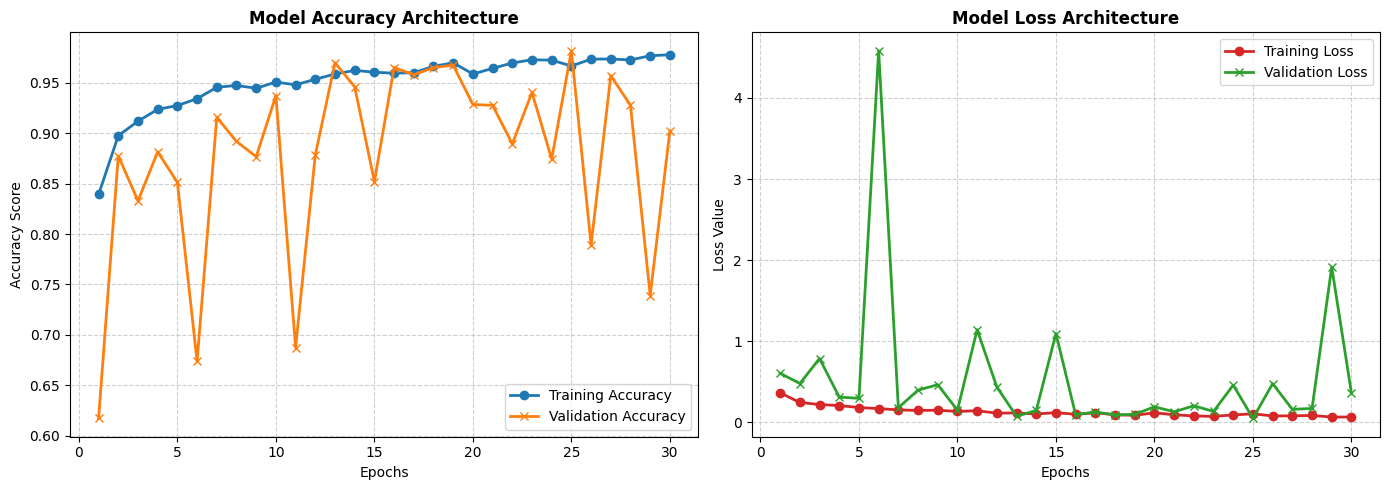

In [12]:
def plot_training_history(history):
    """
    Plots Training vs Validation metrics (Loss and Accuracy) 
    side-by-side from the Keras training history object.
    """
    # 1. Extract metric lists from the history dictionary
    acc = history.history.get('accuracy', history.history.get('acc'))
    val_acc = history.history.get('val_accuracy', history.history.get('val_acc'))
    loss = history.history.get('loss')
    val_loss = history.history.get('val_loss')
    
    epochs_range = range(1, len(loss) + 1)

    # 2. Setup matplotlib figure layout (1 row, 2 columns)
    plt.figure(figsize=(14, 5))

    # 📈 Plot 1: Accuracy Graph
    plt.subplot(1, 2, 1)
    if acc and val_acc:
        plt.plot(epochs_range, acc, label='Training Accuracy', color='#1f77b4', linewidth=2, marker='o')
        plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='#ff7f0e', linewidth=2, marker='x')
        plt.title('Model Accuracy Architecture', fontsize=12, fontweight='bold')
        plt.xlabel('Epochs', fontsize=10)
        plt.ylabel('Accuracy Score', fontsize=10)
        plt.legend(loc='lower right')
        plt.grid(True, linestyle='--', alpha=0.6)

    # 📉 Plot 2: Loss Graph
    plt.subplot(1, 2, 2)
    if loss and val_loss:
        plt.plot(epochs_range, loss, label='Training Loss', color='#d62728', linewidth=2, marker='o')
        plt.plot(epochs_range, val_loss, label='Validation Loss', color='#2ca02c', linewidth=2, marker='x')
        plt.title('Model Loss Architecture', fontsize=12, fontweight='bold')
        plt.xlabel('Epochs', fontsize=10)
        plt.ylabel('Loss Value', fontsize=10)
        plt.legend(loc='upper right')
        plt.grid(True, linestyle='--', alpha=0.6)

    # 3. Render and save the plots cleanly
    plt.tight_layout()
    
    # 💾 Optional: Auto-save the plot as an image for your thesis report
    # plt.savefig("training_performance_curves.png", dpi=300)
    
    plt.show()
plot_training_history(history)


🎬 Executing direct image path inference test...
🎯 Inference Result: 🟢 POLYP


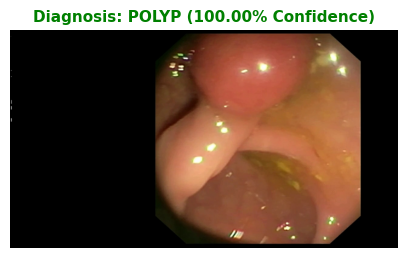

In [16]:
POSITIVE_TEST_IMAGE = "/mnt/c/development/Thesis/PolypSegmentationBasedClassification/DataSets/PolypGen2021_MultiCenterData_v2/imagesAll_positive/seq4_C6_36.jpg"
print("\n🎬 Executing direct image path inference test...")

predict_image_path(model, POSITIVE_TEST_IMAGE)


🎬 Executing direct image path inference test...
🎯 Inference Result: 🔴 NON-POLYP


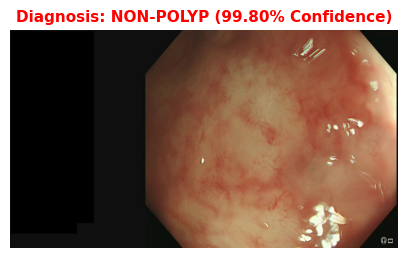

In [19]:
NEGATIVE_TEST_IMAGE = "/mnt/c/development/Thesis/PolypSegmentationBasedClassification/DataSets/PolypGen2021_MultiCenterData_v2/sequenceData/negativeOnly/seq11_neg/EndoCV2021_C5_seq1_102.jpg"
print("\n🎬 Executing direct image path inference test...")

predict_image_path(model, NEGATIVE_TEST_IMAGE)